In [2]:
import sys; sys.path.append('..')
from osp import *

In [13]:
comparisons = []
for cmp in COMPARISONS:
    cmp = [list(x) for x in cmp]
    cmp[0][0]+=" (JoP)"
    cmp[1][0]+=" (PMLA)"
    cmp[0][1] += f" & journal in ['The Journal of Philosophy']"
    cmp[1][1] += f" & journal in ['PMLA']"
    comparisons.append(tuple(tuple(x) for x in cmp))
comparisons

[(('1900-1925 Philosophy (JoP)',
   'discipline=="Philosophy" & 1900<=year<1925 & journal in [\'The Journal of Philosophy\']'),
  ('1900-1925 Literature (PMLA)',
   'discipline=="Literature" & 1900<=year<1925 & journal in [\'PMLA\']')),
 (('1925-1950 Philosophy (JoP)',
   'discipline=="Philosophy" & 1925<=year<1950 & journal in [\'The Journal of Philosophy\']'),
  ('1925-1950 Literature (PMLA)',
   'discipline=="Literature" & 1925<=year<1950 & journal in [\'PMLA\']')),
 (('1950-1975 Philosophy (JoP)',
   'discipline=="Philosophy" & 1950<=year<1975 & journal in [\'The Journal of Philosophy\']'),
  ('1950-1975 Literature (PMLA)',
   'discipline=="Literature" & 1950<=year<1975 & journal in [\'PMLA\']')),
 (('1975-2000 Philosophy (JoP)',
   'discipline=="Philosophy" & 1975<=year<2000 & journal in [\'The Journal of Philosophy\']'),
  ('1975-2000 Literature (PMLA)',
   'discipline=="Literature" & 1975<=year<2000 & journal in [\'PMLA\']')),
 (('2000-2025 Philosophy (JoP)',
   'discipline=="Ph

In [14]:
df_preds, df_feats, d_models = get_preds_feats(comparisons,_force=True)

## 1900-1925 Philosophy (JoP) vs 1900-1925 Literature (PMLA)


100%|██████████| 10/10 [00:11<00:00,  1.16s/it]


## 1925-1950 Philosophy (JoP) vs 1925-1950 Literature (PMLA)


100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


## 1950-1975 Philosophy (JoP) vs 1950-1975 Literature (PMLA)


100%|██████████| 10/10 [00:10<00:00,  1.01s/it]


## 1975-2000 Philosophy (JoP) vs 1975-2000 Literature (PMLA)


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


## 2000-2025 Philosophy (JoP) vs 2000-2025 Literature (PMLA)


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]


In [60]:
# df_preds

In [ ]:
odf = df_preds.groupby(['id','predict_type']).mean(numeric_only=True).reset_index()

In [99]:
odf2 = odf.melt(id_vars=['id','predict_type'],value_vars=[x for x in odf if x.startswith('prob_') and 'Philosophy' in x],var_name='prob_type',value_name='prob')
odf2['prob']*=100
odf2['period_model'] = odf2['prob_type'].apply(lambda x: x.split('_')[1].split(' ')[0])
odf2['text_id'] = odf2['id'].apply(lambda x: x.split('__')[0])
odf2 = odf2.merge(get_corpus_metadata(), left_on='text_id', right_index=True)

def get_journal(jrnl, disc):
    if jrnl == 'The Journal of Philosophy':
        return 'JoP'
    elif jrnl == 'PMLA':
        return 'PMLA'
    else:
        return 'Other '+disc

odf2['journal'] = [get_journal(jrnl, disc) for jrnl, disc in zip(odf2['journal'], odf2['discipline'])]
# odf2 = odf2.groupby(['year','predict_type','discipline','period_model']).mean(numeric_only=True).reset_index()
odf2 = get_avgs_df(odf2.query('predict_type == "unseen" & period_model>="1925"'),['year','predict_type','discipline','period_model'],y='prob').reset_index()
# odf2.journal.value_counts()

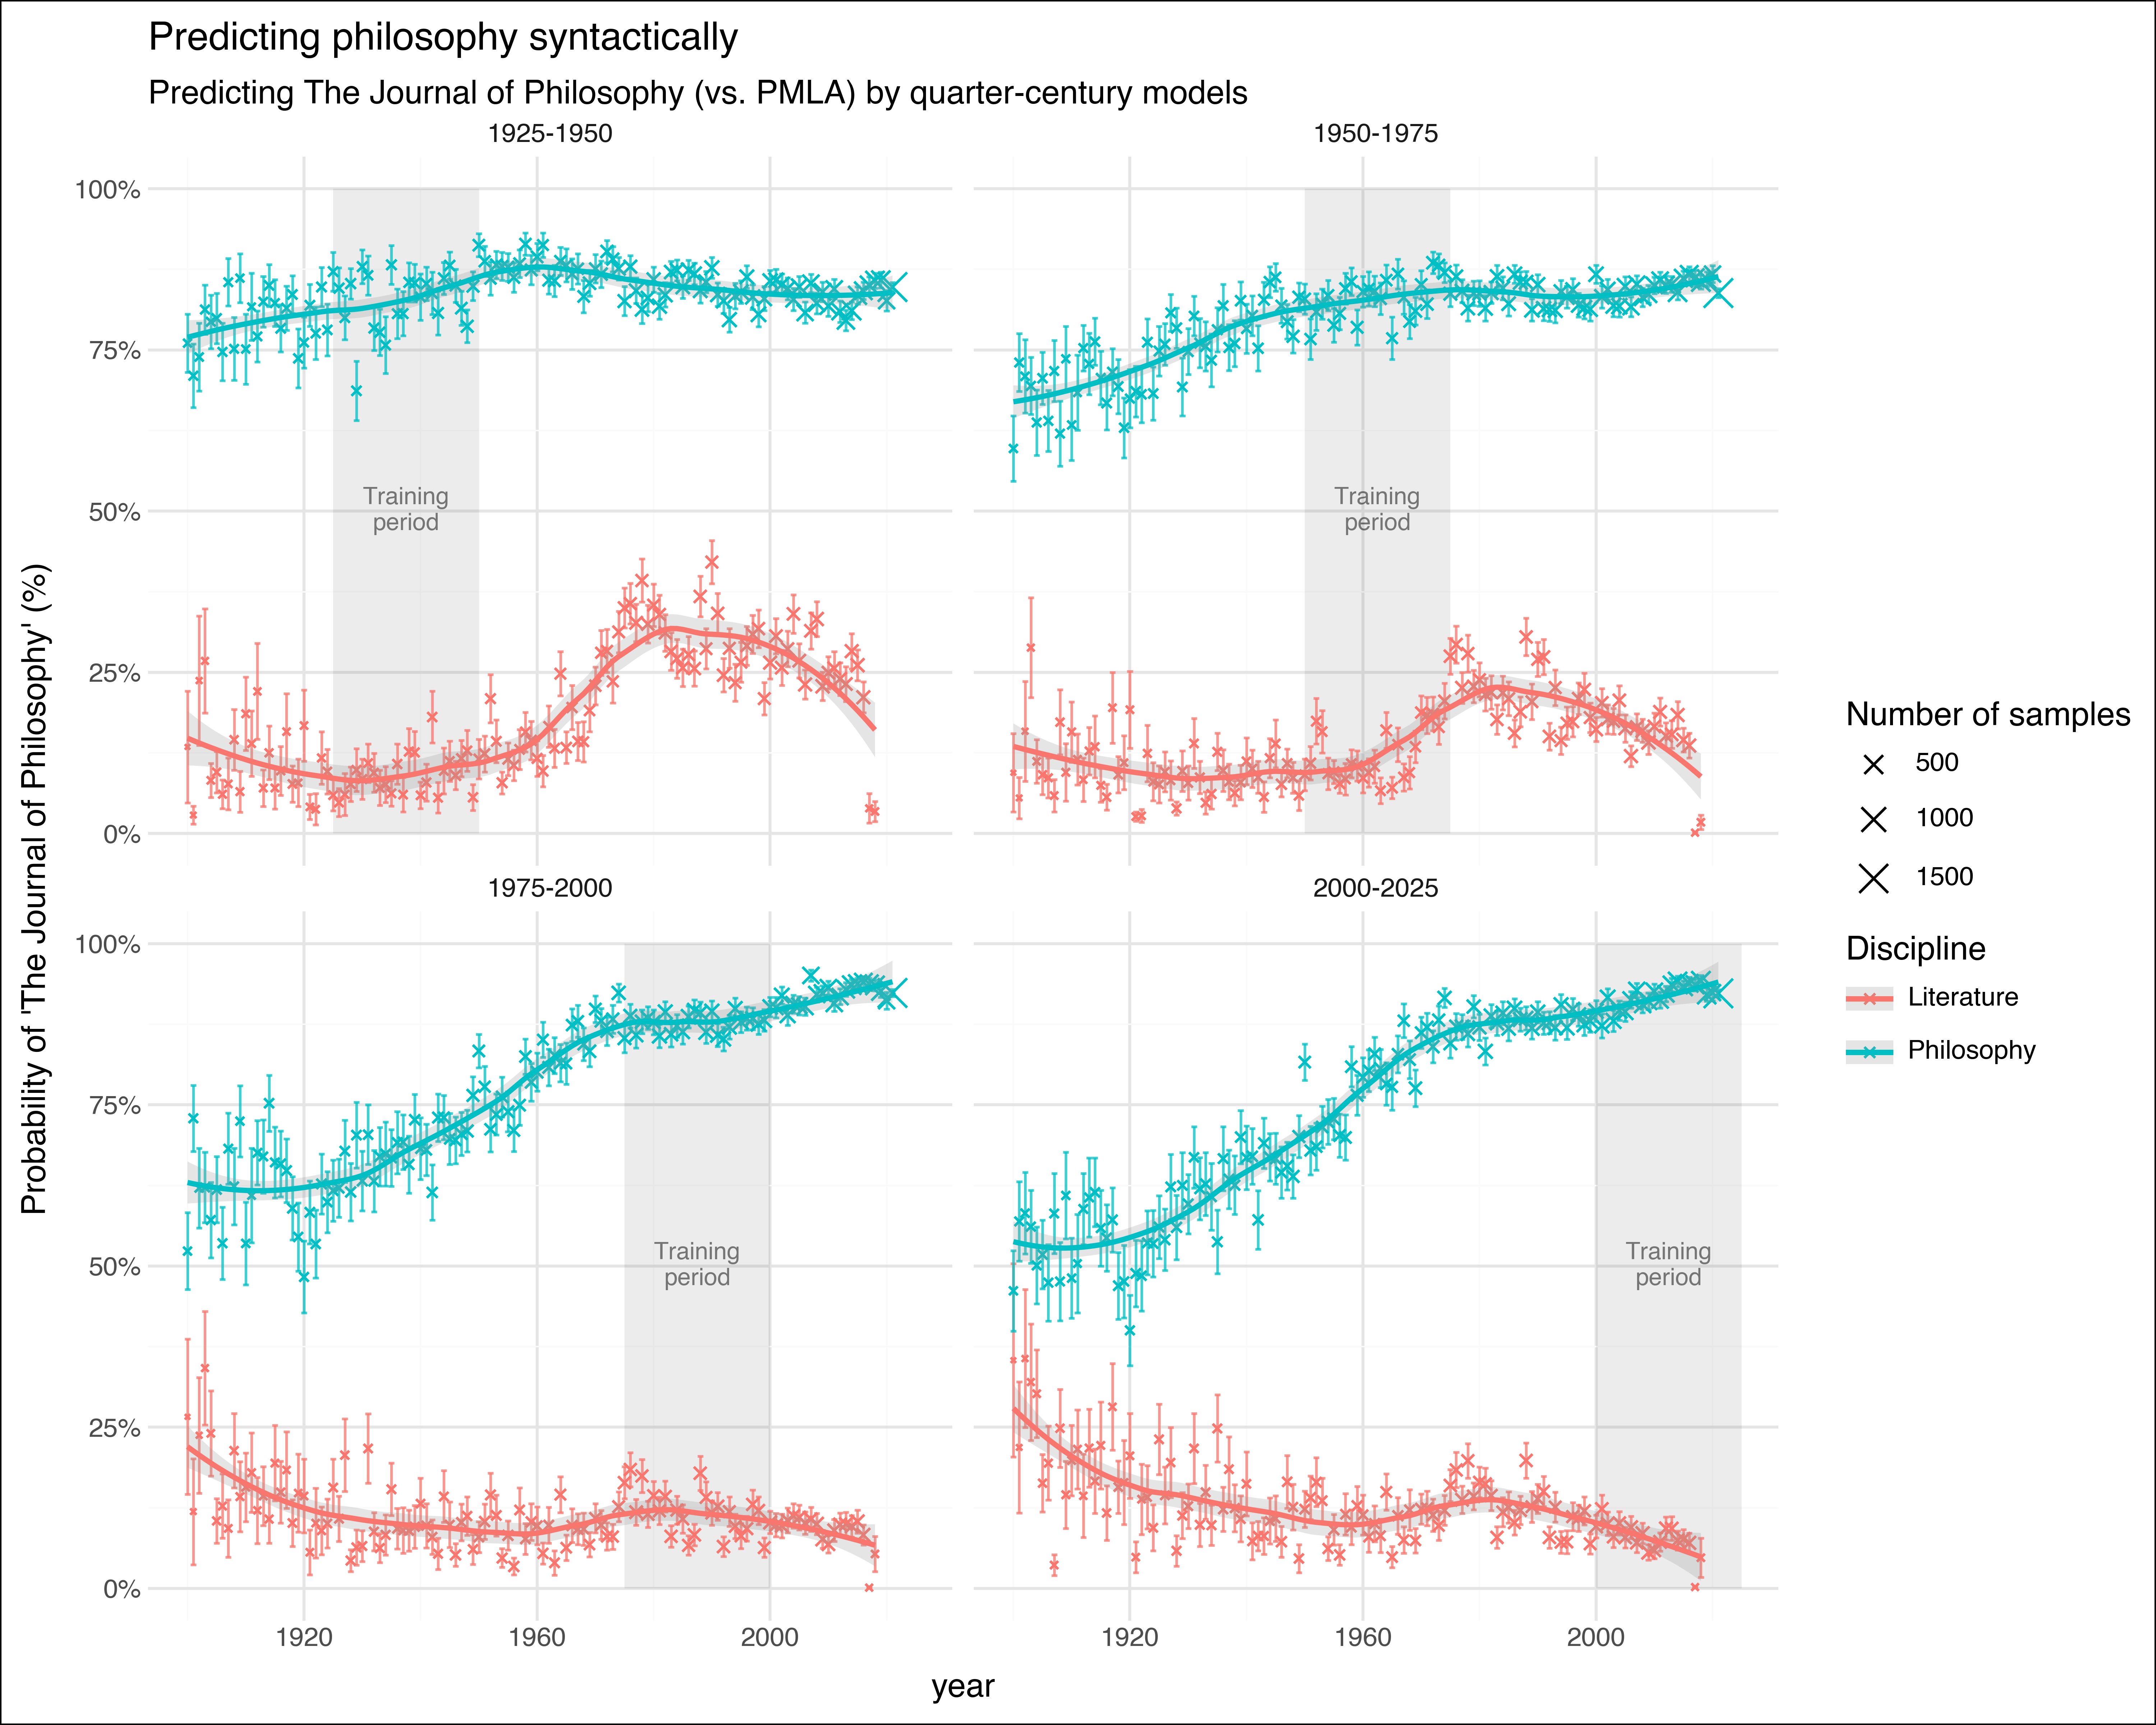

In [101]:
def plot_preds(figdf, facet_col='comparison', **labs):
    band_defs = pd.DataFrame([
        dict(period_model='1925-1950', xmin=1925, xmax=1950, label='Training\nperiod'),
        dict(period_model='1950-1975', xmin=1950, xmax=1975, label='Training\nperiod'),
        dict(period_model='1975-2000', xmin=1975, xmax=2000, label='Training\nperiod'),
        dict(period_model='2000-2025', xmin=2000, xmax=2025, label='Training\nperiod'),
    ])
    band_defs['ymin'] = 0
    band_defs['ymax'] = 100

    fig = (
        p9.ggplot(
            figdf,
            p9.aes(x='year', y='mean', color='discipline'),
        )
        + p9.geom_rect(
            p9.aes(xmin='xmin', xmax='xmax', ymin='ymin', ymax='ymax'),
            data=band_defs,
            inherit_aes=False,
            fill='gray',
            alpha=0.15,
        )
        + p9.geom_text(
            p9.aes(x='xmin + (xmax-xmin)/2', y=50, label='label'),
            data=band_defs,
            inherit_aes=False,
            alpha=.5,
            # ha='left',
            size=8,
        )
        + p9.geom_errorbar(p9.aes(ymin='mean-stderr', ymax='mean+stderr'), width=1, alpha=0.75)
        + p9.geom_point(p9.aes(y='mean',size='count'), shape='x')
        + p9.facet_wrap(facet_col)
        + p9.theme_minimal()
        + p9.scale_size_continuous(range=(.5, 5))
        + p9.scale_y_continuous(labels=lambda l: [f'{int(v)}%' for v in l])
        + p9.geom_smooth(method='loess', span=0.5, alpha=0.25, size=1)
        + p9.labs(**labs)
        + p9.theme(
            plot_background=p9.element_rect(fill='white'),
            plot_title=p9.element_text(ha='left',size=13),
            plot_subtitle=p9.element_text(ha='left',size=11),
        )
    )
    return fig


fig = plot_preds(
    odf2, 
    facet_col='period_model', 
    title='Predicting philosophy syntactically', 
    y="Probability of 'The Journal of Philosophy' (%)",
    subtitle="Predicting The Journal of Philosophy (vs. PMLA) by quarter-century models",
    size='Number of samples',
    shape='Prediction type',
    color='Discipline',
)
fig.save('../figures/preds_by_period_jop.png')
fig

In [97]:

figdf = get_avgs_df(odf,['comparison','discipline','year','decade','predict_type'],y='correct').reset_index()
figdf['mean']*=100

fig = plot_preds(
    figdf, 
    title="Predicting philosophy syntactically", 
    y="Accuracy of discipline prediction (%)",
    subtitle="Accuracy scores by model training period",
    size='Number of samples',
    shape='Prediction type',
    color='Discipline',
)
fig.save('../figures/preds_by_comparison.png')
fig

KeyError: 'comparison'

In [6]:
comparisons = sorted(df_feats.comparison.unique())
comparisons

['1900-1925 Philosophy vs 1900-1925 Literature',
 '1925-1950 Philosophy vs 1925-1950 Literature',
 '1950-1975 Philosophy vs 1950-1975 Literature',
 '1975-2000 Philosophy vs 1975-2000 Literature',
 '2000-2025 Philosophy vs 2000-2025 Literature']

In [34]:
o = []
for cmp in comparisons:
    df_cmp = df_feats[df_feats.comparison == cmp]
    g1,g2 = cmp.split(' vs ')
    period = int(cmp.split('-')[0])
    meancol1 = f'mean_{g1}'
    meancol2 = f'mean_{g2}'
    
    for i,row in df_cmp.iterrows():
        feat = row['feature']
        raw1 = float(row[meancol1])
        raw2 = float(row[meancol2])
        weight = row['weight']


        odx = {'feat': feat, 'feat_type': feat.split('_')[0], 'period': period, 'mean1': raw1, 'mean2': raw2, 'weight': weight, 'comparison': cmp, 'mean_diff': raw1 - raw2}
        o.append(odx)

odf = pd.DataFrame(o)
odf[odf.period==1900].sort_values('weight', ascending=False)

,feat,feat_type,period,mean1,mean2,weight,comparison,mean_diff
61,pos_NN,pos,1900,0.202163,-0.792170,1.210699,1900-1925 Philosophy vs 1900-1925 Literature,0.994333
29,deprel_nmod,deprel,1900,0.421042,-0.002823,0.975336,1900-1925 Philosophy vs 1900-1925 Literature,0.423864
64,pos_NNS,pos,1900,-0.278908,-0.546365,0.768563,1900-1925 Philosophy vs 1900-1925 Literature,0.267457
28,deprel_mark,deprel,1900,-0.123549,-0.795709,0.747265,1900-1925 Philosophy vs 1900-1925 Literature,0.672160
48,pos_CC,pos,1900,0.604726,0.006938,0.719714,1900-1925 Philosophy vs 1900-1925 Literature,0.597788
...,...,...,...,...,...,...,...,...
62,pos_NNP,pos,1900,-0.525119,1.141156,-0.801226,1900-1925 Philosophy vs 1900-1925 Literature,-1.666275
66,pos_POS,pos,1900,-0.563618,0.217228,-0.871326,1900-1925 Philosophy vs 1900-1925 Literature,-0.780846
98,ttr_mean,ttr,1900,0.317987,0.247548,-0.991623,1900-1925 Philosophy vs 1900-1925 Literature,0.070439
9,deprel_case,deprel,1900,0.415585,0.248035,-1.019154,1900-1925 Philosophy vs 1900-1925 Literature,0.167551


In [39]:
from scipy import stats

# Linear regression of weight by period for each feature
regression_results = []
by = 'weight'

for feat in odf['feat'].unique():
    df_feat = odf[odf['feat'] == feat].sort_values('period')
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_feat['period'], df_feat[by])
    vals = df_feat[by].values

    
    regression_results.append({
        'feat': feat,
        'feat_type': feat.split('_')[0],
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err,
        'weight': ' '.join(f'{v:.2f}' for v in df_feat['weight'].values),
        'mean_diff': ' '.join(f'{v:.2f}' for v in df_feat['mean_diff'].values),
        'mean1': ' '.join(f'{float(v):.2f}' for v in df_feat['mean1'].values),
        'mean2': ' '.join(f'{float(v):.2f}' for v in df_feat['mean2'].values),
    })

regression_df = pd.DataFrame(regression_results).sort_values('slope', ascending=False)
regression_df.head(20)

,feat,feat_type,slope,intercept,r_squared,p_value,std_err,weight,mean_diff,mean1,mean2
4,deprel_advmod,deprel,0.018297,-35.094143,0.771249,0.050080,0.005753,-0.12 -0.36 0.64 1.55 1.21,0.54 0.48 0.53 0.60 0.76,0.09 0.00 0.16 0.23 0.26,-0.45 -0.48 -0.37 -0.37 -0.50
9,deprel_case,deprel,0.017242,-33.780755,0.972797,0.001920,0.001665,-1.02 -0.72 0.02 0.29 0.63,0.17 -0.09 -0.57 -0.65 -0.83,0.42 0.25 -0.15 -0.18 -0.43,0.25 0.34 0.43 0.47 0.40
12,deprel_compound,deprel,0.016988,-33.057924,0.582677,0.133195,0.008300,-0.62 -0.84 0.02 1.37 0.40,-0.32 -0.32 -0.08 0.30 0.11,-0.71 -0.67 -0.44 0.01 0.55,-0.39 -0.35 -0.36 -0.30 0.45
52,pos_FW,pos,0.010970,-21.852393,0.596469,0.125869,0.005210,-1.16 -0.85 -0.21 0.28 -0.35,-1.05 -0.61 -0.47 -0.22 -0.36,-0.18 -0.10 -0.14 -0.13 -0.15,0.87 0.51 0.33 0.09 0.20
8,deprel_aux:pass,deprel,0.010772,-20.873538,0.838605,0.028980,0.002728,-0.31 -0.42 0.32 0.49 0.58,0.18 0.45 0.57 0.44 0.36,0.41 0.46 0.38 0.12 -0.10,0.22 0.01 -0.18 -0.32 -0.47
14,deprel_conj,deprel,0.010681,-21.197345,0.740384,0.061248,0.003652,-0.69 -0.99 -0.40 0.16 0.07,0.12 -0.02 -0.38 -0.79 -1.06,0.40 0.41 0.04 -0.34 -0.49,0.27 0.43 0.42 0.45 0.58
22,deprel_discourse,deprel,0.009931,-19.191571,0.680579,0.085556,0.003928,-0.31 -0.37 0.48 0.65 0.42,-0.47 -0.45 0.05 0.29 0.32,-0.13 -0.21 -0.01 0.06 0.13,0.34 0.25 -0.06 -0.23 -0.20
36,deprel_obj,deprel,0.009125,-17.905296,0.405498,0.247953,0.006379,-0.11 -1.00 -0.20 0.44 0.31,-0.08 -0.27 -0.04 0.05 0.20,-0.48 -0.55 -0.24 0.07 0.32,-0.41 -0.27 -0.20 0.02 0.13
89,sent_DC,sent,0.008782,-16.812415,0.932479,0.007603,0.001364,-0.12 -0.01 0.41 0.62 0.66,0.64 0.57 0.84 0.74 0.88,-0.18 -0.20 0.23 0.31 0.43,-0.83 -0.77 -0.61 -0.43 -0.45
73,pos_SYM,pos,0.008573,-16.829940,0.953575,0.004306,0.001092,-0.45 -0.43 -0.11 0.07 0.36,-0.05 -0.03 0.00 0.19 0.31,-0.20 -0.20 -0.10 0.07 0.19,-0.15 -0.17 -0.11 -0.12 -0.13
